In [5]:
import pandas as pd 

In [6]:
df = pd.read_csv("addiction_data.csv")
print(df.head())
print(df.tail())
print(df.shape)

   screen_time_hours  social_media_minutes  phone_checks_per_day  \
0                  1                    30                    20   
1                  2                    45                    25   
2                  2                    60                    30   
3                  3                    90                    40   
4                  3                   100                    45   

   sleep_disturbance  anxiety addiction  
0                  0        0   Healthy  
1                  0        0   Healthy  
2                  0        0   Healthy  
3                  0        0   Healthy  
4                  1        0   At Risk  
    screen_time_hours  social_media_minutes  phone_checks_per_day  \
24                  4                   130                    55   
25                  5                   175                    75   
26                  6                   225                    95   
27                  7                   265                   1

In [7]:
df.to_csv("addiction_data.csv",index=False)

In [9]:
pd.read_csv("addiction_data.csv").head()

,screen_time_hours,social_media_minutes,phone_checks_per_day,sleep_disturbance,anxiety,addiction
0,1,30,20,0,0,Healthy
1,2,45,25,0,0,Healthy
2,2,60,30,0,0,Healthy
3,3,90,40,0,0,Healthy
4,3,100,45,1,0,At Risk


In [10]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['addiction_encoded'] = le.fit_transform(df['addiction'])

df[['addiction','addiction_encoded']]

,addiction,addiction_encoded
0,Healthy,2
1,Healthy,2
2,Healthy,2
3,Healthy,2
4,At Risk,1
5,At Risk,1
6,At Risk,1
7,At Risk,1
8,Addicted,0
9,Addicted,0


In [13]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['addiction_encoded'] = le.fit_transform(df['addiction'])

df[['addiction','addiction_encoded']]

,addiction,addiction_encoded
0,Healthy,2
1,Healthy,2
2,Healthy,2
3,Healthy,2
4,At Risk,1
5,At Risk,1
6,At Risk,1
7,At Risk,1
8,Addicted,0
9,Addicted,0


In [14]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("addiction_data.csv")

encoder = LabelEncoder()
df['addiction_encoded'] = encoder.fit_transform(df['addiction'])

print(df[['addiction','addiction_encoded']])

print("Label mapping:")
for label, value in zip(encoder.classes_,encoder.transform(encoder.classes_)):
    print(label, "->", value)

   addiction  addiction_encoded
0    Healthy                  2
1    Healthy                  2
2    Healthy                  2
3    Healthy                  2
4    At Risk                  1
5    At Risk                  1
6    At Risk                  1
7    At Risk                  1
8   Addicted                  0
9   Addicted                  0
10  Addicted                  0
11  Addicted                  0
12  Addicted                  0
13  Addicted                  0
14   Healthy                  2
15   Healthy                  2
16   Healthy                  2
17   At Risk                  1
18   At Risk                  1
19  Addicted                  0
20  Addicted                  0
21  Addicted                  0
22   Healthy                  2
23   Healthy                  2
24   At Risk                  1
25   At Risk                  1
26  Addicted                  0
27  Addicted                  0
28  Addicted                  0
Label mapping:
Addicted -> 0
At Risk -> 

In [15]:
X = df.drop('addiction',axis=1)
Y = df['addiction_encoded']

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, y_test, = train_test_split(
    X,Y,
    test_size=0.2,
    random_state=42,
)

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)
print("model accuracy",accuracy) 

model accuracy 1.0


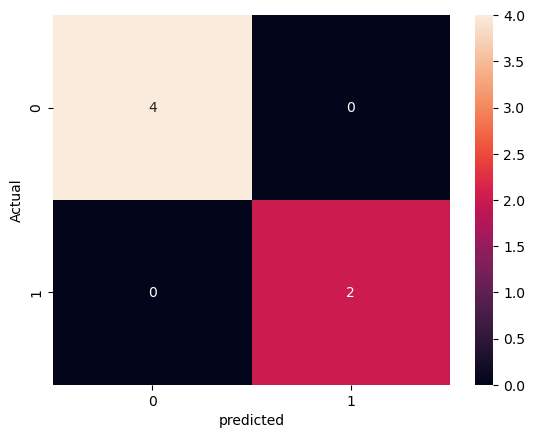

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,annot=True, fmt='d')
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.show()


In [22]:
new_user = [[
    6,
    120,
    8,
    1,
    0,
    0
]]

prediction = model.predict(new_user)
print("predicted addiction level(encoded):",prediction)

predicted addiction level(encoded): [1]


C:\Users\Sneha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [23]:
predicted_label = encoder.inverse_transform(prediction)
print("predicted Addition level:",predicted_label[0])

predicted Addition level: At Risk


In [24]:
import joblib

joblib.dump(model,"mobile_addiction_model.pkl")
joblib.dump(encoder,"label_encoder.pkl")

['label_encoder.pkl']

In [25]:
loaded_model = joblib.load("mobile_addiction_model.pkl")
loaded_encoder = joblib.load("label_encoder.pkl")

test_pred = loaded_model.predict(new_user)
print("loaded_model prediction:",loaded_encoder.inverse_transform(test_pred)[0])

loaded_model prediction: At Risk


C:\Users\Sneha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train,Y_train)
rf_pred = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Random Forest Accuracy:",accuracy_score(y_test,rf_pred))

Random Forest Accuracy: 0.8333333333333334


In [27]:
from sklearn.metrics import classification_report
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       0.00      0.00      0.00         0
           2       1.00      1.00      1.00         2

    accuracy                           0.83         6
   macro avg       0.67      0.58      0.62         6
weighted avg       1.00      0.83      0.90         6



C:\Users\Sneha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Sneha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Sneha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
